In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.utilities import ricker_wavelet, green2d

In [ ]:
layers = [
        (350.0, 1500.0, 2000.0), # top layer
        (450.0, 4000.0, 2000.0),
        (600.0, 2500.0, 1500.0), # bottom halfspace
    ]

In [4]:
param = Parameters(total_time=1.0, nt=512, freq=25., nfft=1024)

# x and z positions of sources
sources = [(80.0, 76.0), (150.0, 76.0), (250.0, 76.0), (350.0, 76.0), (480.0, 76.0), (620.0, 76.0)]
# x and z positions of receivers
Nr = 128
x_receivers = np.linspace(0.0, 700.0, Nr)
receivers = [(x, 76.0) for x in x_receivers]
print(receivers)
acq = Acquisition(sources, receivers)

[(np.float64(0.0), 76.0), (np.float64(5.511811023622047), 76.0), (np.float64(11.023622047244094), 76.0), (np.float64(16.53543307086614), 76.0), (np.float64(22.04724409448819), 76.0), (np.float64(27.559055118110237), 76.0), (np.float64(33.07086614173228), 76.0), (np.float64(38.58267716535433), 76.0), (np.float64(44.09448818897638), 76.0), (np.float64(49.60629921259842), 76.0), (np.float64(55.118110236220474), 76.0), (np.float64(60.62992125984252), 76.0), (np.float64(66.14173228346456), 76.0), (np.float64(71.65354330708661), 76.0), (np.float64(77.16535433070867), 76.0), (np.float64(82.67716535433071), 76.0), (np.float64(88.18897637795276), 76.0), (np.float64(93.7007874015748), 76.0), (np.float64(99.21259842519684), 76.0), (np.float64(104.7244094488189), 76.0), (np.float64(110.23622047244095), 76.0), (np.float64(115.74803149606299), 76.0), (np.float64(121.25984251968504), 76.0), (np.float64(126.77165354330708), 76.0), (np.float64(132.28346456692913), 76.0), (np.float64(137.79527559055117)

In [5]:
d_cal = forward(layers, acq, param, free_surface=False, nq_prop=256, nq_evan=64)

Ricker wavelet initialized with delay: 0.1 s
kx quadrature elapsed: 3.51 s


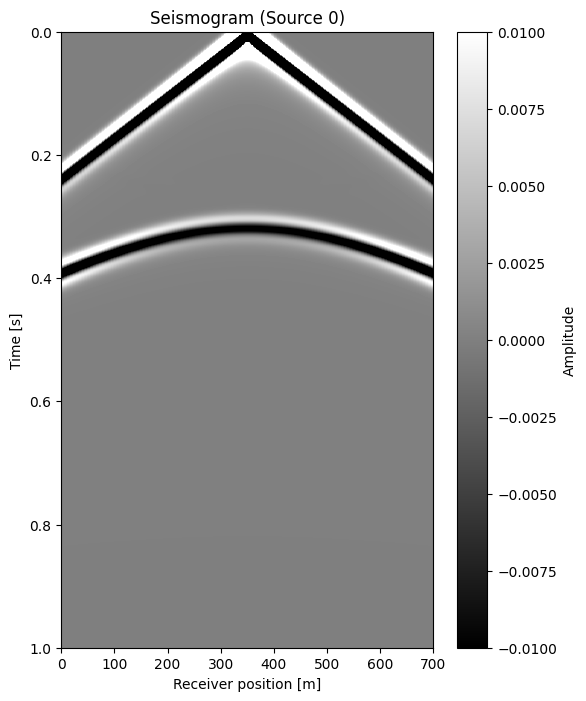

In [6]:
d_cal_seis = d_cal[3, :, :]

plt.figure(figsize=(6,8))
plt.imshow(d_cal_seis.T, aspect='auto', origin='upper', 
           extent=[np.min(acq.xr), np.max(acq.xr), param.time[-1], param.time[0]],
           cmap='gray', vmin=-0.01, vmax=0.01)
plt.colorbar(label='Amplitude')
plt.xlabel('Receiver position [m]')
plt.ylabel('Time [s]')
plt.title('Seismogram (Source 0)')
plt.show()

Reflection coeff: 0.45454545454545453
r_dist 90.94488188976379 r_travel 555.4952488923223


(-0.05, 0.05)

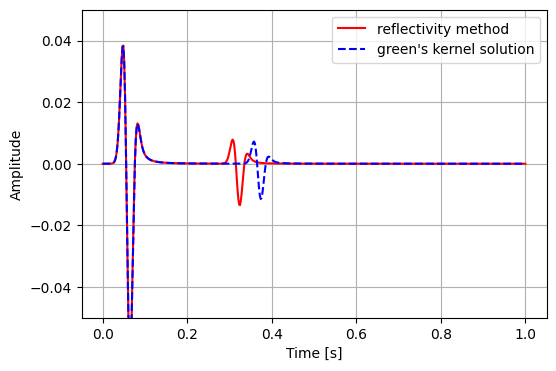

In [7]:
# validation with green's function in frequency domain
freqs = np.fft.rfftfreq(param.nfft, param.dt)
omegas = 2.0 * np.pi * freqs  + 1j * 1e-12
s_t, delay = ricker_wavelet(param.time, param.freq)
s_w = np.conj(np.fft.rfft(np.conj(s_t), n=param.nfft)) 

Reflection = (layers[1][1] - layers[0][1])/(layers[0][1] + layers[1][1])
print("Reflection coeff:", Reflection)
vp = layers[0][1]
h = layers[0][0]
r_dist = np.sqrt( (acq.xs[3] - acq.xr[80])**2 + (acq.zs[3] - acq.zr[80])**2 )
r_travel = 2.*np.sqrt( (h-acq.zs[3])**2 + (0.5*(acq.xs[3] - acq.xr[80]))**2 )

print("r_dist", r_dist, "r_travel", r_travel)
T_ref = s_w*(green2d(omegas, vp, r_dist) + Reflection*green2d(omegas, vp, r_travel)) * np.exp(-1j * delay * omegas)
S_ref = np.conj(np.fft.irfft(np.conj(T_ref), n=param.nfft))
S_ref = S_ref[:param.nt]

plt.figure(figsize=(6,4))
plt.plot(param.time, d_cal[3, 80, :], 'r-', label='reflectivity method')
plt.plot(param.time, S_ref, 'b--', label='green\'s kernel solution')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.ylim(-0.05, 0.05)

In [8]:
from src.misfit import l2_misfit
misfit = l2_misfit(d_cal[3, 80, :], S_ref, layers=layers, acqui=acq, param=param)
print("L2 misfit between reflectivity and green's function solution:", misfit)

L2 misfit between reflectivity and green's function solution: 0.0010354444258315419
